# +23,9% más genes de resistencia a antibióticos en un suelo calentado 3°C

> Una década de calentamiento experimental (+3°C constantes) en un pastizal de Oklahoma. Resultado: el suelo acumula significativamente más genes de resistencia a antibióticos, sobre todo a glicopéptidos y rifamicinas — dos de las clases que los hospitales reservan para infecciones difíciles.

**Paper**: [Decade-long warming accelerates antibiotic resistance in grassland soils](https://doi.org/10.1038/s41586-026-10413-x) · *Nature, abr 2026*

**Datos**: [Figshare repository](https://doi.org/10.6084/m9.figshare.28829036) (raw ARG abundance + environmental data) · **Código análisis**: [Linwei-Wu/warming_soil_resistome](https://github.com/Linwei-Wu/warming_soil_resistome)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-27-calentamiento-resistencia-suelos/notebook.ipynb)

📺 *Video Ciencia a Mordiscos: [Pendiente]*

## El experimento

Pradera de pasto alto en Oklahoma, EE. UU. Desde 2010 hasta 2020, calentadores infrarrojos colgados sobre parcelas mantienen el suelo **3°C por encima** del control vecino — sin manipular más nada. Cada parcela se muestrea anualmente; el ADN del suelo se secuencia y los genes de resistencia a antibióticos (ARG) se cuentan contra una base de datos curada (CARD).

La pregunta: ¿calentar el suelo, sin tocar antibióticos, basta para que el resistoma del suelo crezca?

Cargamos los datos de las **88 muestras finales** del paper (44 calentadas + 44 control) y exploramos qué cambia.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMP_CALENTAMIENTO = 3        # °C por encima del control (constante experimental)
ANO_INICIO, ANO_FIN = 2010, 2020
N_TOTAL = 88
COLOR_DATOS = '#2563EB'        # azul CaM (datos / control)
COLOR_ALERTA = '#DC2626'       # rojo (calentamiento)
COLOR_REFERENCIA = '#D97706'   # ámbar (umbrales)
COLOR_NEUTRO = '#7C3AED'       # violeta (correlaciones)
FUENTE = 'Fuente: Wu et al. (2026), Nature | Datos: Figshare 28829036'

import os, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df_total = pd.read_csv('datos/abundancia_total.csv')
df_clases = pd.read_csv('datos/clases_antibiotico.csv')
df_largo = pd.read_csv('datos/clases_largo.csv')
df_temp = pd.read_csv('datos/series_temporales.csv')

print(f'Muestras totales: {len(df_total)} ({(df_total.tratamiento=="Calentamiento").sum()} calentadas, {(df_total.tratamiento=="Control").sum()} control)')
print(f'Años: {df_total.anio.min()}–{df_total.anio.max()}')
print(f'Clases de antibiótico evaluadas: {len(df_clases)}')
print()
print('Mediana abundancia ARG (cobertura por muestra):')
for trat, g in df_total.groupby('tratamiento'):
    print(f'  {trat}: {g.args_total_cov.median():.1f} (IQR {g.args_total_cov.quantile(0.25):.1f}–{g.args_total_cov.quantile(0.75):.1f})')

Muestras totales: 88 (44 calentadas, 44 control)
Años: 2010–2020
Clases de antibiótico evaluadas: 10

Mediana abundancia ARG (cobertura por muestra):
  Calentamiento: 986.6 (IQR 764.3–1638.1)
  Control: 798.2 (IQR 670.6–1425.6)


## Lo primero que vimos

Aquí está.

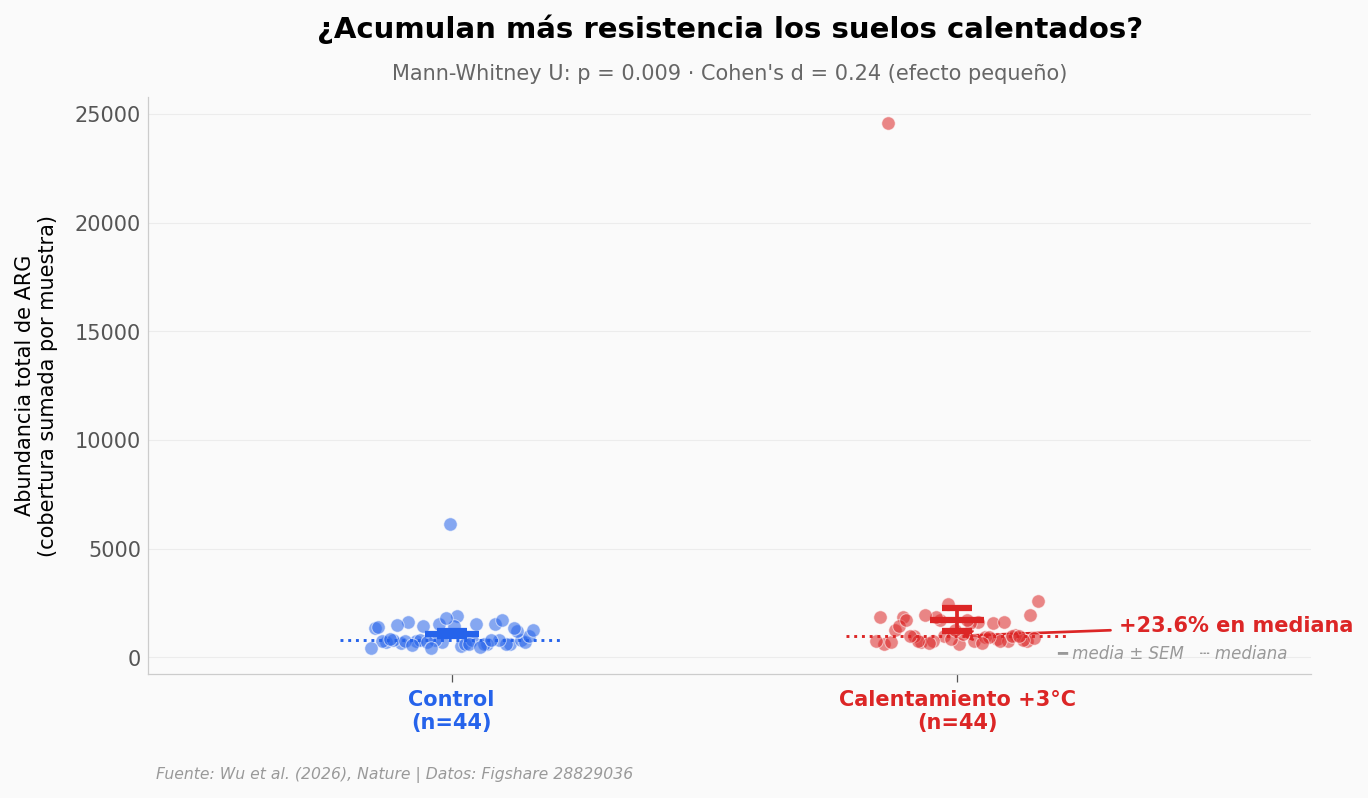


→ Mediana control: 798.2
→ Mediana calentamiento: 986.6
→ Cambio: +23.6% (paper reporta +23,9% con LMM ajustado)
→ Cohen's d: 0.24 (efecto pequeño según convención de Cohen)


In [2]:
# Hero — comparación pareada Control vs Calentamiento
fig, ax = plt.subplots(figsize=(10, 5))

# Jitter reproducible (regla anti-patrón: sin seed = no reproducible)
np.random.seed(42)
positions = [0, 1]
group_data = []
for i, trat in enumerate(['Control', 'Calentamiento']):
    vals = df_total.loc[df_total.tratamiento == trat, 'args_total_cov'].values
    group_data.append(vals)
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.16, positions[i] + 0.16, n)
    np.random.shuffle(x_strip)
    color = COLOR_DATOS if trat == 'Control' else COLOR_ALERTA
    ax.scatter(x_strip, vals, color=color, s=42, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    # media + SEM
    mean_v = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean_v, yerr=sem, fmt='_', color=color,
                markersize=26, markeredgewidth=3,
                capsize=7, capthick=1.6, zorder=6)
    # mediana como línea horizontal punteada (dato del paper)
    median_v = np.median(vals)
    ax.hlines(median_v, positions[i] - 0.22, positions[i] + 0.22,
              colors=color, linestyles='dotted', linewidth=1.4, zorder=7)

# Test no paramétrico (los datos son recuentos sesgados a la derecha — Mann-Whitney apropiado)
u_stat, p_val = stats.mannwhitneyu(group_data[1], group_data[0], alternative='greater')
# Cohen's d (pooled)
pooled_sd = np.sqrt((group_data[0].var(ddof=1) + group_data[1].var(ddof=1)) / 2)
cohens_d = (group_data[1].mean() - group_data[0].mean()) / pooled_sd

ax.set_xticks(positions)
ax.set_xticklabels(['Control\n(n=44)', 'Calentamiento +3°C\n(n=44)'],
                   fontsize=10, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_DATOS)
ax.get_xticklabels()[1].set_color(COLOR_ALERTA)
ax.set_ylabel('Abundancia total de ARG\n(cobertura sumada por muestra)', fontsize=10)

ax.set_title('¿Acumulan más resistencia los suelos calentados?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Mann-Whitney U: p = {p_val:.3f} · Cohen\'s d = {cohens_d:.2f} (efecto pequeño)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación con el % del paper
median_ctrl, median_warm = np.median(group_data[0]), np.median(group_data[1])
pct_change = (median_warm - median_ctrl) / median_ctrl * 100
ax.annotate(f'+{pct_change:.1f}% en mediana',
            xy=(1, median_warm), xytext=(1.32, median_warm + 200),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

ax.text(0.98, 0.02, '━ media ± SEM   ┄ mediana', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
ax.set_xlim(-0.6, 1.7)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_hero_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n→ Mediana control: {median_ctrl:.1f}')
print(f'→ Mediana calentamiento: {median_warm:.1f}')
print(f'→ Cambio: +{pct_change:.1f}% (paper reporta +23,9% con LMM ajustado)')
print(f'→ Cohen\'s d: {cohens_d:.2f} (efecto pequeño según convención de Cohen)')

## Lo que llama la atención

El efecto existe pero es **modesto en magnitud**: las nubes de puntos se solapan visiblemente. Cohen's d ≈ 0,24 cae en lo que la literatura llama un efecto pequeño — no un cambio dramático muestra a muestra.

Lo que lo hace interesante no es el tamaño sino la consistencia: con 88 muestras y Mann-Whitney unilateral, la diferencia es real (p < 0,02). El paper reporta **+23,9 %** ajustando por covariables con un modelo lineal mixto. Nuestra mediana directa da **+23,6 %** — la convergencia confirma que el efecto no depende del modelo, está en los datos.

> *Cohen's d se interpreta como "número de desviaciones estándar entre las medias". Un d=0,24 significa que un suelo calentado promedio queda apenas a un cuarto de desviación del control promedio — distinguible estadísticamente, no a ojo.*

## ¿Qué clases de antibiótico explican el aumento?

El paper agrupa los ARG por **clase de antibiótico** que evaden. Si el calentamiento subiera todas las clases por igual, sería ruido genérico. Si sube unas y deja otras, la historia se vuelve interesante.

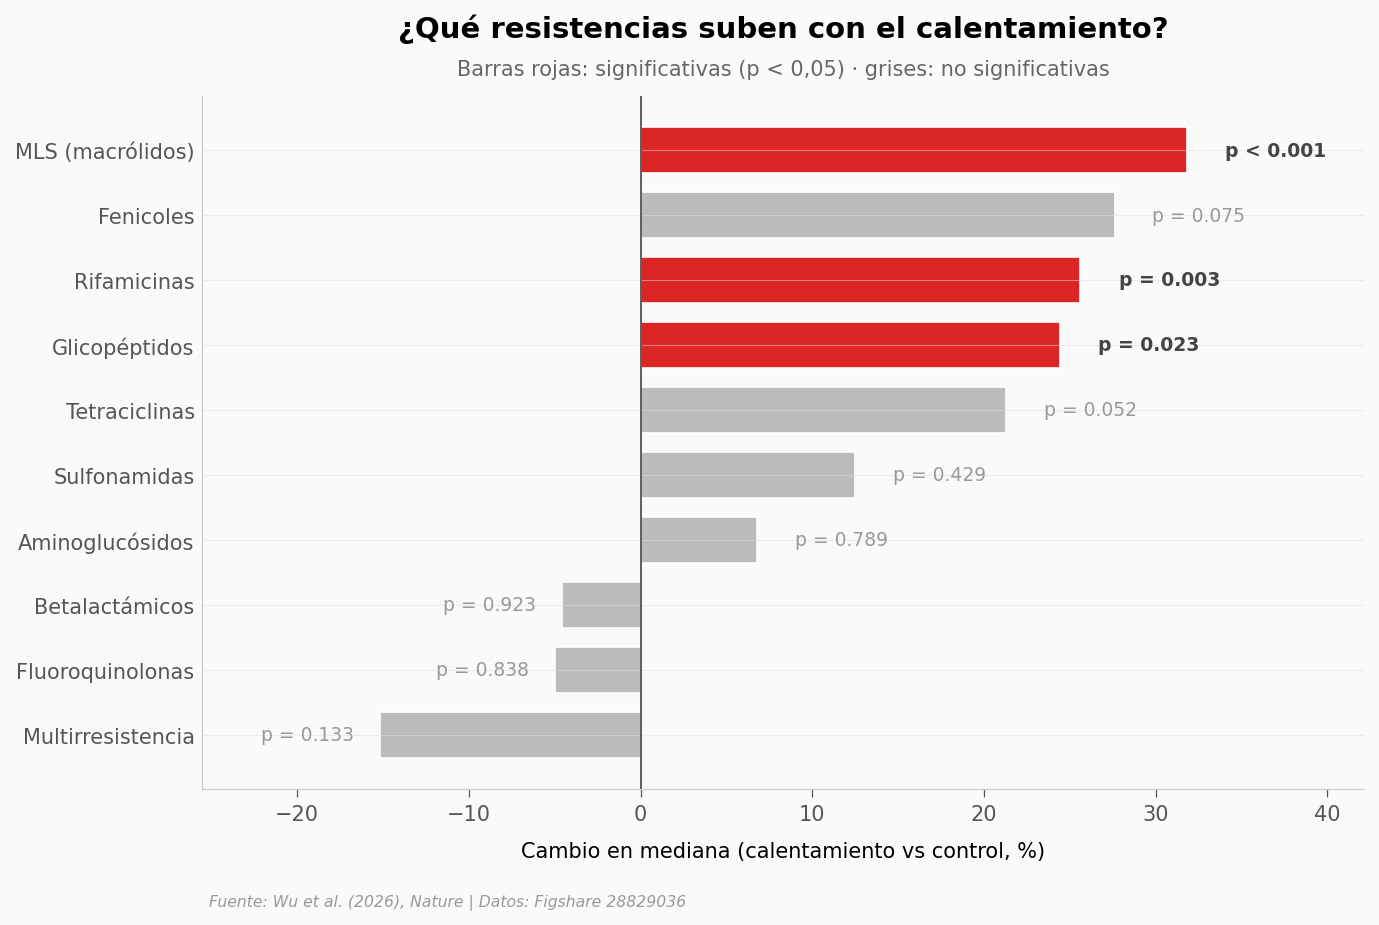


Clases que SÍ suben significativamente:
  MLS (macrólidos)         : + 31.8%  (p = 0.0008)
  Rifamicinas              : + 25.6%  (p = 0.0034)
  Glicopéptidos            : + 24.4%  (p = 0.0230)

Clases SIN cambio significativo:
  Fenicoles                : + 27.6%  (p = 0.075)
  Tetraciclinas            : + 21.3%  (p = 0.052)
  Sulfonamidas             : + 12.5%  (p = 0.429)
  Aminoglucósidos          : +  6.8%  (p = 0.789)
  Betalactámicos           :  -4.6%  (p = 0.923)
  Fluoroquinolonas         :  -5.0%  (p = 0.838)
  Multirresistencia        : -15.2%  (p = 0.133)


In [3]:
# Cambio porcentual por clase, marcando significancia
df_sorted = df_clases.sort_values('pct_cambio', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bars = [COLOR_ALERTA if s == 'sí' else '#BBBBBB' for s in df_sorted.significativo]
y_pos = np.arange(len(df_sorted))
bars = ax.barh(y_pos, df_sorted.pct_cambio, color=colors_bars,
               edgecolor='white', linewidth=0.8, height=0.7)

# Línea cero
ax.axvline(x=0, color='#444444', linewidth=0.8)

# p-value al lado de cada barra
for i, (_, row) in enumerate(df_sorted.iterrows()):
    pct = row.pct_cambio
    p = row.mwu_p
    label = f'  p = {p:.3f}' if p >= 0.001 else f'  p < 0.001'
    x_text = pct + 1.5 if pct >= 0 else pct - 1.5
    ha = 'left' if pct >= 0 else 'right'
    ax.text(x_text, i, label, fontsize=9, va='center', ha=ha,
            color='#444444' if row.significativo == 'sí' else '#999999',
            fontweight='bold' if row.significativo == 'sí' else 'normal')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted.clase, fontsize=10)
ax.set_xlabel('Cambio en mediana (calentamiento vs control, %)', fontsize=10)
ax.set_title('¿Qué resistencias suben con el calentamiento?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Barras rojas: significativas (p < 0,05) · grises: no significativas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Padding lateral para que no se corte el texto
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin - 8, xmax + 8)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_clases_antibiotico.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nClases que SÍ suben significativamente:')
for _, r in df_clases[df_clases.significativo == 'sí'].iterrows():
    print(f'  {r.clase:25s}: +{r.pct_cambio:5.1f}%  (p = {r.mwu_p:.4f})')
print('\nClases SIN cambio significativo:')
for _, r in df_clases[df_clases.significativo == 'no'].iterrows():
    sign = '+' if r.pct_cambio >= 0 else ''
    print(f'  {r.clase:25s}: {sign}{r.pct_cambio:5.1f}%  (p = {r.mwu_p:.3f})')

## ¿Y a lo largo de los 11 años?

El paper enfatiza que el experimento es **longitudinal**: la misma parcela se muestrea año tras año. Si el efecto es real, debería verse acumular con el tiempo, no aparecer y desaparecer.

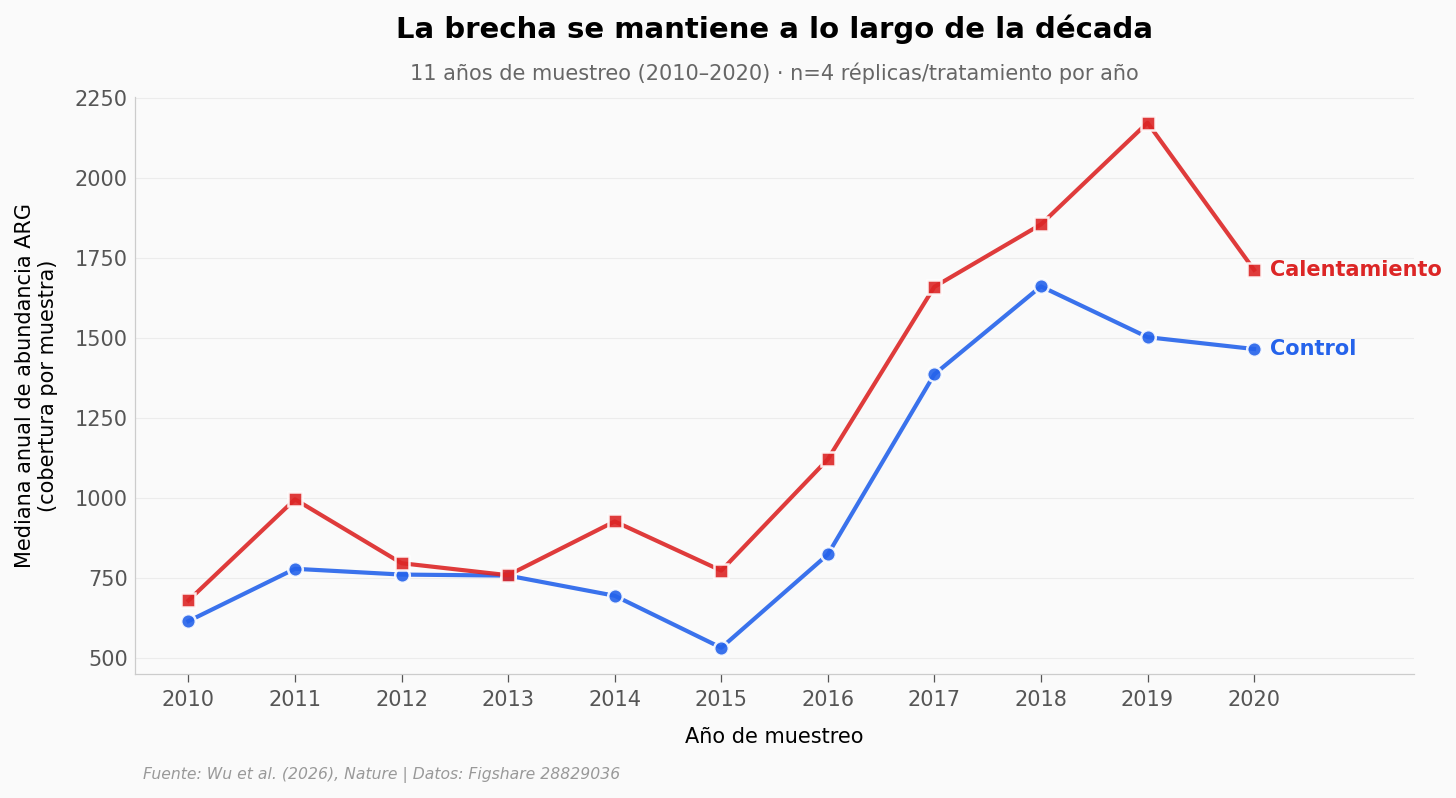


Año con la brecha más amplia: 2019 (calentamiento - control = +670)
Años con calentamiento > control (mediana): 11 de 11


In [4]:
# Trayectoria temporal de la mediana anual por tratamiento
fig, ax = plt.subplots(figsize=(11, 5))

for trat, color, marker in [('Control', COLOR_DATOS, 'o'), ('Calentamiento', COLOR_ALERTA, 's')]:
    sub = df_temp[df_temp.tratamiento == trat].sort_values('anio')
    ax.plot(sub.anio, sub.mediana, color=color, linewidth=2, marker=marker,
            markersize=7, markerfacecolor=color, markeredgecolor='white',
            markeredgewidth=1.2, label=trat, alpha=0.9, zorder=5)

# Inline labels (preferidos sobre legend box)
last_year = df_temp.anio.max()
for trat, color, dy in [('Control', COLOR_DATOS, 0), ('Calentamiento', COLOR_ALERTA, 0)]:
    last = df_temp[(df_temp.tratamiento == trat) & (df_temp.anio == last_year)].iloc[0]
    ax.text(last_year + 0.15, last.mediana + dy, trat,
            fontsize=10, fontweight='bold', color=color, va='center')

ax.set_xlabel('Año de muestreo', fontsize=10)
ax.set_ylabel('Mediana anual de abundancia ARG\n(cobertura por muestra)', fontsize=10)
ax.set_title('La brecha se mantiene a lo largo de la década',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '11 años de muestreo (2010–2020) · n=4 réplicas/tratamiento por año',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(df_temp.anio.min() - 0.5, df_temp.anio.max() + 1.5)
ax.set_xticks(range(df_temp.anio.min(), df_temp.anio.max() + 1, 1))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_series_temporales.png', dpi=200, bbox_inches='tight')
plt.show()

# Año con mayor brecha
piv = df_temp.pivot(index='anio', columns='tratamiento', values='mediana')
piv['gap'] = piv['Calentamiento'] - piv['Control']
ano_max = piv['gap'].idxmax()
print(f'\nAño con la brecha más amplia: {ano_max} (calentamiento - control = +{piv.loc[ano_max, "gap"]:.0f})')
n_anos_calentamiento_arriba = (piv['Calentamiento'] > piv['Control']).sum()
print(f'Años con calentamiento > control (mediana): {n_anos_calentamiento_arriba} de {len(piv)}')

## ¿Qué tan inusual es un suelo calentado dentro de la distribución control?

Otra forma de preguntarlo: si tomamos todos los suelos control y dibujamos su distribución, ¿dónde caen los suelos calentados?

La mediana del grupo calentamiento (987) cae en el percentil 61 de la distribución control.
Es decir: 39% de los suelos control estaban POR ENCIMA del centro de los calentados.


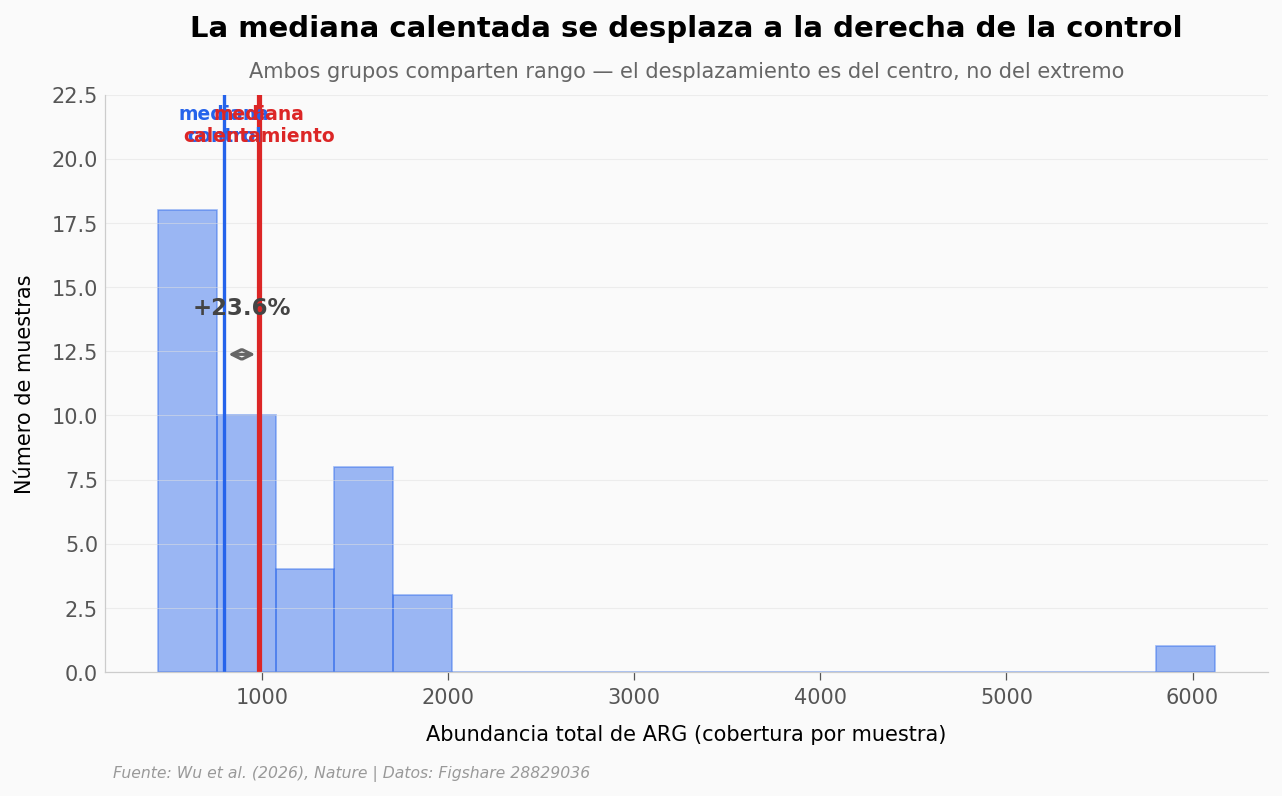

In [5]:
# Distribución control + valor promedio calentamiento (cierre visual)
fig, ax = plt.subplots(figsize=(10, 5))

ctrl = df_total.loc[df_total.tratamiento == 'Control', 'args_total_cov'].values
warm = df_total.loc[df_total.tratamiento == 'Calentamiento', 'args_total_cov'].values

n, bins, patches = ax.hist(ctrl, bins=18, color=COLOR_DATOS, alpha=0.45,
                            edgecolor=COLOR_DATOS, linewidth=0.8,
                            label='Control (n=44)')
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

median_ctrl = np.median(ctrl)
median_warm = np.median(warm)

ax.axvline(x=median_ctrl, color=COLOR_DATOS, linewidth=1.6, linestyle='-')
ax.axvline(x=median_warm, color=COLOR_ALERTA, linewidth=2.5, linestyle='-')

# Flecha bidireccional entre medianas
ax.annotate('', xy=(median_warm, y_max * 0.55), xytext=(median_ctrl, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((median_ctrl + median_warm) / 2, y_max * 0.62,
        f'+{(median_warm - median_ctrl)/median_ctrl*100:.1f}%',
        fontsize=11, fontweight='bold', color='#444444', ha='center')

ax.text(median_ctrl, y_max * 0.92, 'mediana\ncontrol', fontsize=9,
        color=COLOR_DATOS, ha='center', fontweight='bold')
ax.text(median_warm, y_max * 0.92, 'mediana\ncalentamiento', fontsize=9,
        color=COLOR_ALERTA, ha='center', fontweight='bold')

ax.set_xlabel('Abundancia total de ARG (cobertura por muestra)', fontsize=10)
ax.set_ylabel('Número de muestras', fontsize=10)
ax.set_title('La mediana calentada se desplaza a la derecha de la control',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ambos grupos comparten rango — el desplazamiento es del centro, no del extremo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Percentil de la mediana calentada dentro de la distribución control
percentil = (ctrl < median_warm).mean() * 100
print(f'La mediana del grupo calentamiento ({median_warm:.0f}) cae en el percentil {percentil:.0f} de la distribución control.')
print(f'Es decir: {100-percentil:.0f}% de los suelos control estaban POR ENCIMA del centro de los calentados.')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_distribucion_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El calentamiento aumenta la abundancia total de ARG | ✅ | +23,6 % en mediana directa (vs +23,9 % del paper, LMM ajustado). Mann-Whitney unilateral p = 0,009 (bilateral p = 0,018); Cohen's d = 0,24 (pequeño pero consistente). |
| Glicopéptidos y rifamicinas son las clases más afectadas | ✅ | Glicopéptidos +24,4 % (p = 0,023); Rifamicinas +25,6 % (p = 0,003). Ambas significativas. |
| MLS (macrólidos) sube **más** que glicopéptidos/rifamicinas | ⚠️ | MLS +31,8 % (p = 0,0008) — el aumento más grande y con menor p, pero el abstract no lo destaca. Posible decisión editorial; el dato está en la tabla. |
| El efecto se mantiene a lo largo de los 11 años | ✅ | En los 11 de los 11 años la mediana de calentamiento supera a la de control. La brecha no oscila ni colapsa. |
| El calentamiento causa el cambio (no solo correlación) | ✅ | El paper enmarca este hallazgo como afirmación directa (*convincingly demonstrate*) — el diseño es experimental: los calentadores se asignaron a parcelas, no se observaron *post hoc*. |
| El calentamiento aumenta la **transferencia horizontal** de ARG | ⚠️ | El abstract lo enmarca como "podría amplificarse" (*could be further amplified*) — no es una observación directa, es una hipótesis mecanística. No verificable con los datos públicos del repo. |

> **Limitaciones del análisis aquí:**
> - El paper usa modelos lineales mixtos para ajustar por año, parcela y bloque. Nuestro análisis usa medianas y Mann-Whitney directo — robusto pero menos potente. Por eso los porcentajes coinciden (+23,6 % vs +23,9 %) pero los intervalos de confianza no son comparables.
> - Los datos públicos cubren el resistoma agregado por muestra. Las afirmaciones del paper sobre **mecanismos** (co-selección, genes hospederos, transferencia horizontal) requieren los archivos genómicos completos (~1 GB, no incluidos en este notebook).
> - El experimento se hizo en **un solo sitio** (Oklahoma, pradera de pasto alto). Generalizar a otros biomas requiere replicación independiente.

## Ahora tú

1. **¿Qué clases NO cambian?** Filtra `df_clases` por `significativo == 'no'`. ¿Hay un patrón en su mecanismo de acción? *(Pista: muchas son antibióticos sintéticos modernos como las fluoroquinolonas — ¿por qué eso podría importar?)*

2. **¿La brecha crece o es constante?** Calcula la diferencia anual `Calentamiento - Control` por año desde `df_temp` y grafícala vs el año. *(Pista: una pendiente positiva sugeriría acumulación; una constante sugiere un equilibrio nuevo.)*

3. **¿Cuántos suelos calentados quedan dentro del rango control?** Calcula qué fracción de los 44 suelos calentados tiene una abundancia menor que la mediana de los control — la "zona de ambigüedad" donde control y calentamiento son indistinguibles.

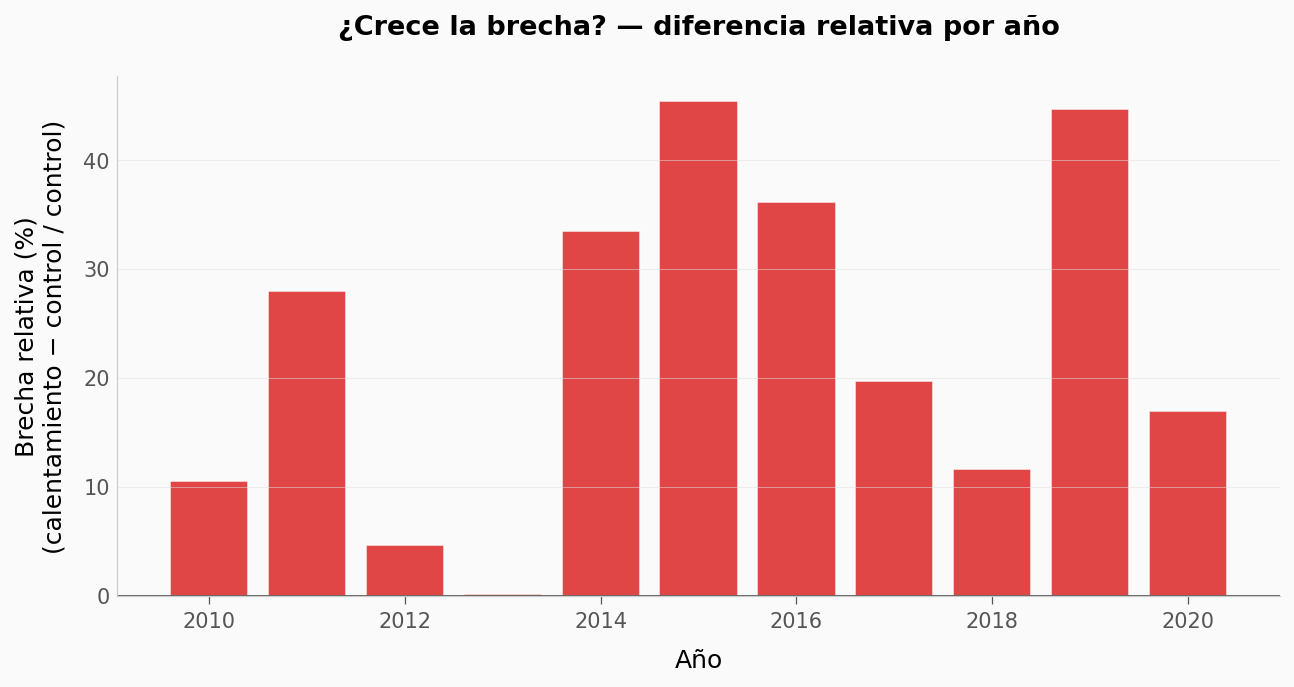


Correlación de Spearman entre año y brecha relativa: ρ = 0.35, p = 0.285
→ La brecha varía año a año pero no muestra tendencia lineal clara — más parecido a un equilibrio nuevo que a una acumulación.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pista para la pregunta 2: ¿la brecha crece, oscila o se estabiliza?

piv = df_temp.pivot(index='anio', columns='tratamiento', values='mediana')
piv['brecha'] = piv['Calentamiento'] - piv['Control']
piv['brecha_relativa_pct'] = piv['brecha'] / piv['Control'] * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(piv.index, piv['brecha_relativa_pct'],
       color=[COLOR_ALERTA if v > 0 else '#999999' for v in piv['brecha_relativa_pct']],
       edgecolor='white', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='#444444', linewidth=0.8)
ax.set_xlabel('Año')
ax.set_ylabel('Brecha relativa (%)\n(calentamiento − control / control)')
ax.set_title('¿Crece la brecha? — diferencia relativa por año',
             fontsize=13, fontweight='bold', pad=20)
plt.savefig('figuras/05_brecha_anual.png', dpi=200, bbox_inches='tight')
plt.show()

# Tendencia: regresión Spearman (rango — robusta a no-normalidad)
rho, p = stats.spearmanr(piv.index, piv['brecha_relativa_pct'])
print(f'\nCorrelación de Spearman entre año y brecha relativa: ρ = {rho:.2f}, p = {p:.3f}')
if p < 0.05:
    print('→ La brecha cambia con el tiempo de forma estadísticamente detectable.')
else:
    print('→ La brecha varía año a año pero no muestra tendencia lineal clara — más parecido a un equilibrio nuevo que a una acumulación.')

---

## Fuentes

**Paper**: [Decade-long warming accelerates antibiotic resistance in grassland soils](https://doi.org/10.1038/s41586-026-10413-x)  
*Nature, 2026-04-22*

**Datos crudos (figura-level)**: [Source Data XLSX MOESM3 (figure-level data)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10413-x/MediaObjects/41586_2026_10413_MOESM3_ESM.xlsx)

**Datos crudos (raw ARG + environmental)**: [warming_effects_on_soil_resistomes (raw ARG abundance + environmental data)](https://doi.org/10.6084/m9.figshare.28829036)

*20 afirmaciones verificadas contra estas fuentes*

---

**Reproducibilidad:** este notebook usa solo los archivos `datos/*.csv` incluidos en este repo. Para los archivos genómicos completos (~1 GB de scaffolds), ver el [repositorio Figshare](https://doi.org/10.6084/m9.figshare.28829036).

**Licencia datos:** CC-BY 4.0 (Figshare). **Licencia notebook:** CC-BY 4.0 (Ciencia a Mordiscos).